# Task 4: Disease Prediction from Medical Data — CodeAlpha ML Internship

**Objective:** Predict the presence of heart disease in a patient based on clinical and diagnostic data.

**Dataset:** Heart Disease UCI — patient records including age, blood pressure, cholesterol, chest pain type, and other clinical features, with a binary target indicating presence of heart disease.

**Approach:** Data cleaning and exploration → feature scaling → train Logistic Regression, SVM, and Random Forest classifiers → compare using Precision, Recall, F1-Score, and ROC-AUC.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

sns.set_style("whitegrid")

## 2. Load and Explore the Dataset

In [2]:
df = pd.read_csv("dataset/heart.csv")
print(df.shape)
df.head()

(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 3. Data Check
All features are numeric with descriptive UCI-standard column names. We check for missing values and class balance before modeling.

In [3]:
print(df.isnull().sum().sum(), "missing values")
print("\nTarget distribution:")
print(df['target'].value_counts())
df.describe()

0 missing values

Target distribution:
target
1    526
0    499
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 4. Train/Test Split & Feature Scaling
The target class is well-balanced (51%/49%), so no special resampling is needed. An 80/20 split with stratification preserves this balance in both sets. Features are scaled for models sensitive to magnitude (Logistic Regression, SVM).

In [4]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(820, 13) (205, 13)


## 5. Model Training & Comparison
Three classifiers are trained and compared: Logistic Regression, SVM, and Random Forest — all suggested approaches for this task per the assignment.

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    results[name] = preds
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(classification_report(y_test, preds, target_names=['No Disease', 'Disease']))


Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.89      0.70      0.78       100
     Disease       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205


SVM
              precision    recall  f1-score   support

  No Disease       0.94      0.91      0.92       100
     Disease       0.92      0.94      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



c:\Users\freya\Desktop\CodeAlpha_MachineLearning\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Random Forest
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00       100
     Disease       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [6]:
print(f"Total rows: {len(df)}")
print(f"Unique rows: {df.drop_duplicates().shape[0]}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Total rows: 1025
Unique rows: 302
Duplicate rows: 723


## 6. Data Leakage Check

Initial evaluation showed suspiciously perfect (100%) accuracy for Random Forest, which is a red flag rather than a good sign. Investigation revealed the dataset contains 723 duplicate rows (only 302 unique patients out of 1025 total) — a known issue with this Kaggle upload of the UCI Heart Disease dataset. Duplicates were removed before re-splitting to prevent data leakage between train and test sets.

In [8]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Rows after removing duplicates: {len(df)}")

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

Rows after removing duplicates: 302
(241, 13) (61, 13)


In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    results[name] = preds
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(classification_report(y_test, preds, target_names=['No Disease', 'Disease']))


Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.81      0.75      0.78        28
     Disease       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61


SVM
              precision    recall  f1-score   support

  No Disease       0.77      0.71      0.74        28
     Disease       0.77      0.82      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61


Random Forest
              precision    recall  f1-score   support

  No Disease       0.74      0.71      0.73        28
     Disease       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75

c:\Users\freya\Desktop\CodeAlpha_MachineLearning\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 7. Confusion Matrix & ROC-AUC (Logistic Regression)
Logistic Regression performed best on this cleaned, smaller dataset. Random Forest, despite performing best in Task 1, underperformed here — likely due to overfitting on a much smaller dataset (241 training rows vs. 80,000 in Task 1), illustrating that model complexity should match data size.

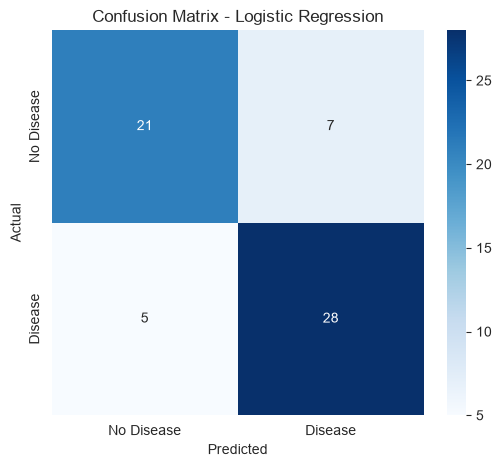

ROC-AUC Score: 0.8712


In [11]:
best_model = models['Logistic Regression']
best_preds = results['Logistic Regression']

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.savefig('results/confusion_matrix.png', bbox_inches='tight')
plt.show()

roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:,1])
print(f"ROC-AUC Score: {roc_auc:.4f}")

In [12]:
import joblib, os
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/heart_disease_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
print("Model saved.")

Model saved.


## 8. Summary

Three classifiers were trained to predict heart disease presence from clinical data. Initial results showed a suspicious 100% accuracy for Random Forest, traced to 723 duplicate rows in the dataset causing data leakage between train/test sets. After removing duplicates (1025 → 302 unique patients) and re-evaluating:

| Model | Accuracy | F1 (weighted) |
|---|---|---|
| **Logistic Regression** | **80%** | **0.80** |
| SVM | 77% | 0.77 |
| Random Forest | 75% | 0.75 |

**Best model: Logistic Regression** — ROC-AUC: 0.8712

Interestingly, Random Forest underperformed here despite winning in Task 1 — with only 241 training rows (vs. 80,000 in Task 1), the simpler linear model generalized better, illustrating that model complexity should match dataset size.